# 회귀분석기반의 예측 모델 이해

과거의 데이터 안에서 규칙을 찾아서 미래값을 계산하는 것이 예측 모델(Forecasting Model)이다. 이 예측 모델의 가장 기반되는 방법이 회귀분석(Regression Analysis)이다.

## 예측

예측(Forecast)은 지금까지 관측한 데이터와 그 안의 규칙을 바탕으로 아직 관측하지 않은 미래 값을 '범위와 함께' 추정하는 일을 의미한다.

좋은 예측은 한 점의 숫자와 함께 그 숫자가 얼마나 틀릴수 있는지를 같이 알려준다. 예측은 미래를 맞히는 확정적인 말이 아니라, 과거의 규칙이 계속된다면 이라는 조건이 붙은 계산 결과이다.

예측은 비슷해보이는 다른 숫자들과 구분이 가능해야된다. 예측과 목표를 섞어서 사용하는 경우가 왕왕있는데, 목표는 이만큼 달성하고싶다에 대한 의지인것이고, 예측은 지금 흐름이면 이만큼 될 것이다 라는 전망이다.

- 예측: 지금 흐름이면 얼마가 될까?, 과거 데이터와 모델
- 목표: 얼마를 달성하고 싶은 것인가?, 정책, 방향
- 계획: 무엇을 준비할것인가?, 예측과 목표를 비교한 후 결정
- 추정: 이미 지난 값은 얼마였는가?, 부분 자료로 계산

### 예측 모델 구성

예측 모델은 입력값(Input)을 넣으면 예측값(Output)을 돌려주는 계산 규칙을 의미한다. 예측 모델은 몇 번째 달인가, 몇 월인가, 명절이 있는가 등의 입력을 받아서 이번달 물동량이 얼마다 라는 예측값을 출력해준다.

- 예측모델
  - 목표값(Target, Y): 맞히고자 하는 값
  - 특성(Feature, X): 목표값을 설명할 수 있는 입력
  - 모델(Model): X와 Y를 잇는 계산규칙(회귀식)
    - 파라미터(Parameter): 학습으로 정해지는 값(회귀계수)
    - 하이퍼파라미터(Hyper Parameter): 사람이 정하는 값
  - 학습(Fit): 과거 데이터로 파라미터를 정하는 과정
  - 예측(Predict): 새 X를 넣어 Y를 계산하는 과정
  - 평가(Evaluate): 모델이 보지 않은 실제 값과의 비교

## 회귀분석

회귀분석(Regression Analysis)은 한 변수(목표값)가 다른 변수(특성)에 따라 어떻게 변하는지를 식으로 나타내는 분석방법이다.

선박의 총톤수가 클수록 하역시간이 길어지는 경향이 있다고 한다면, '총 톤수가 1만톤 늘어날때 하역시간이 평균 몇시간 늘어나겠는가'를 숫자로 알려주는게 회귀분석인 것이다.

설명하려는 값이 종속변수(Dependent Variable), 설명에 쓰이는 값이 독립변수(Independent Variable)이다.

### 회귀분석의 종류

- 단순 선형회귀: 연도 -> 연간 환적 물동량
- 다중 선형회귀: 추세, 월, 명절 -> 월별 환적 물동량
- 다항회귀: 곡선 추세
- 로지스틱 회귀: 확률문제

### 최소제곱법

회귀선(Regression Line)은 흩어진 점들 사이를 가장 잘 지나가는 직선으로 정의할 수 있다. '가장 잘 지나가는'의 기준이 필요하다. 선형회귀(Linear Regression)는 각 점에서 직선까지의 세로거리(잔차(Residual))를 제곱해서 모두 더한 값이 가장 작아지는 직선을 고른다.

이 방법을 최소제곱법(OLS, Ordinary Least Squares)이라고 일컫는다. 잔차가 음수가 나올 수 있기 때문에, 위쪽 잔차와 아래쪽 잔차의 상쇄를 막고, 크게 벗어난 점에 대해서 더 큰 벌점을 주기 위해서다.



In [ ]:
!uv add scikit-learn

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

years = np.array([2018, 2019, 2020, 2021, 2022, 2023])
tranship = np.array([1150, 1170, 1210, 1235, 1185, 1250])

x_mean, y_mean = years.mean(), tranship.mean()
b1 = ((years - x_mean) * (tranship - y_mean)).sum() / ((years - x_mean) ** 2).sum()
b0 = y_mean - b1 * x_mean

print(round(b1, 2)) # 기울기
print(round( b0 + b1 * 2024 , 1))


16.29
1257.0


In [4]:
model = LinearRegression()
model.fit(years.reshape(-1, 1), tranship) # y = wx + b

print(round(model.coef_[0], 2))
print(round(model.intercept_, 1))

16.29
-31705.3


In [5]:
fitted = model.predict(years.reshape(-1, 1))
residuals = tranship - fitted

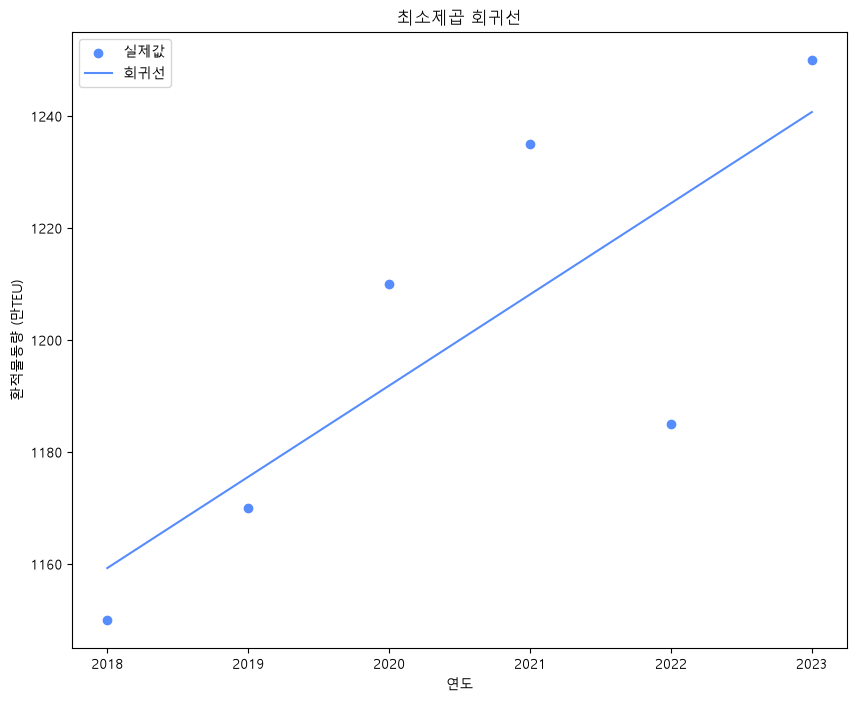

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(years, tranship, label='실제값')
ax.plot(years, fitted, label='회귀선')

ax.set_xlabel('연도')
ax.set_ylabel('환적물동량 (만TEU)')

ax.set_title('최소제곱 회귀선')

ax.legend()

plt.show()


In [10]:
# model.predict([[2024]])[0]
model.predict([[2025]])[0]

np.float64(1273.2857142857174)

## 결정계수 ($R^2$)

회귀선을 그렸으면 '이 직선이 데이터를 얼마나 잘 설명하는가?'를 구체적으로 알고싶어진다. 구체적으로 알고싶어진다는 곧 숫자로 설명하고 싶어진다를 의미한다. 결정계수(Coefficient of Determination)
